## Model loading 

In [ ]:
from transformers import Wav2Vec2Processor,Wav2Vec2ForCTC
from datasets import load_from_disk
import pandas as pd
import torch 

#IPAv2_TonV2 ->  '/Users/evanchan19/Desktop/Thesis_Research/Mostafa_Phono_model/models/cV13_ipav2_tonev2_fixDecouple/fine_tune/best'
path = '/Users/evanchan19/Desktop/Thesis_Research/Mostafa_Phono_model/models/cV13_ipav2_tonev2_sep/fine_tune/best'
processor = Wav2Vec2Processor.from_pretrained(path)
model = Wav2Vec2ForCTC.from_pretrained(path)

date_size = 1500

# 1) Load the datasets and Parameters Settings

In [21]:
from datasets import load_from_disk
import pandas as pd

def build_vowel_consonant_sets(attribute_mapping):
    vowel_set, consonant_set = set(), set()
    for i in range(len(attribute_mapping)):
        row = attribute_mapping.iloc[i]
        ph = str(row["Phoneme_ipaDragon"]).strip()
        if int(row["vowel"]) == 1:
            vowel_set.add(ph)
        else:
            consonant_set.add(ph)
    return vowel_set, consonant_set

data_path = '/Users/evanchan19/Desktop/Thesis_Research/Mostafa_Phono_model/mandarin_p2a_model/datasets/latic_l2_v2'

## Initial settings   ###  Importantant                         STEP 1)
file_path = '/Users/evanchan19/Desktop/Thesis_Research/Mostafa_Phono_model/mandarin_p2a_model/data/Mandarin_List_attr_IPAwithTone_V3_ToneV2.txt'   

# Load the attribute mapping file                               STEP 2)
csv_file_path = '/Users/evanchan19/Desktop/Thesis_Research/Mostafa_Phono_model/mandarin_p2a_model/data/IPAwithTone_p2attr_V3_noDiph_ToneV2_sep.csv'   
attribute_mapping = pd.read_csv(csv_file_path)
vowel_set, consonant_set = build_vowel_consonant_sets(attribute_mapping)

#### !!!!! VERY IMPORTANT                                       STEP 3)
which_type = 'transcript_IPAwithTone_actual'            # This is from the datasets itself !!!
which_sentence = 'sentence_speaker_said'                # This is from the datasets itself !!!
suppose_sentence = 'transcript_IPAwithTone_suppose'

### Chocie can be                   'tone'     or     'IPA'     STEP 4)
choice = 'IpaAndTone' 
is_decouple = True

data = load_from_disk(data_path)
data = data['train']
data = data.select(range(date_size)) 
data

Dataset({
    features: ['audio', 'sentence_speaker_said', 'sentence_supposed_said', 'transcript_IPA_actual', 'tone_pinyin_actual', 'tone_pinyin_suppose', 'transcript_IPA_suppose', 'transcript_IPAwithTone_actual', 'transcript_IPAwithTone_suppose'],
    num_rows: 1500
})

In [22]:
import re
# Filter the Latic Dataset if the number is there
SENTENCE_COLS = [
    "sentence_speaker_said",
    "sentence_supposed_said"
]
_digit_re = re.compile(r"\d")
def no_digit_sentence(example):
    for col in SENTENCE_COLS:
        s = example.get(col, "")
        if s and _digit_re.search(s):
            return False   # 含数字 → 丢弃
    return True

data_filtered = data.filter(no_digit_sentence)
print(f"Before: {len(data)}")
print(f"After : {len(data_filtered)}")
data = data_filtered

Before: 1500
After : 1498


### 2) Function settings

In [ ]:
import re
## Step 1
def load_attribute_list(file_path):
    try:
        with open(file_path) as f:
            list_att = f.read().splitlines()
            return list_att
    except FileNotFoundError:
        raise FileNotFoundError(f"The list of attribute file {file_path} is not found")
             
list_att = load_attribute_list(file_path)

## Step 2 
def create_binary_groups(list_att):
    groups = []
    for att in list_att:
        binary_att = [f'p_{att}', f'n_{att}']  # Each attribute could be +ve or -ve
        groups.append(binary_att)
    return groups

groups = create_binary_groups(list_att)

## Step 3
def get_att_group_indx_map(bTraining=True):
    #Get group ids dictionary
    group_ids = [sorted(processor.tokenizer.convert_tokens_to_ids(group)) for group in groups]
    if bTraining:
        group_ids = [dict([(x[1],x[0]+1) for x in list(enumerate(g))]) for g in group_ids]
    else:
        group_ids = [dict([(x[0]+1,x[1]) for x in list(enumerate(g))]) for g in group_ids]
    return group_ids

group_ids = get_att_group_indx_map(bTraining=False)


## Step 4) Decouple if needed
if choice == 'IpaAndTone':
    decouple_diph_file = '/Users/evanchan19/Desktop/Thesis_Research/Mostafa_Phono_model/mandarin_p2a_model/data/Diphthongs_Mandarin_withTone.csv'
else:
    decouple_diph_file = '/Users/evanchan19/Desktop/Thesis_Research/Mostafa_Phono_model/mandarin_p2a_model/data/Diphthongs_Mandarin.csv'

def merge_separate_tone(phones: list[str]) -> list[str]:

    if len(phones) >= 2 and phones[-1].isdigit():
        return phones[:-2] + [phones[-2] + phones[-1]]
    return phones

def load_diph_map(path: str):
    diph_map = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = [p.strip() for p in line.split(",") if p.strip() != ""]
            key = parts[0]
            vals = parts[1:]
            diph_map[key] = vals  # list of phones
    return diph_map

# 你原来的文件路径逻辑保持不变
diphthongs_to_monophthongs_map = load_diph_map(decouple_diph_file)
IDX_RE = re.compile(r"^(.*?)(\d+)$")  # 匹配末尾数字，如 iɑʊ4 / wa2 / ai12
def decouple_token(tok: str):

    m = IDX_RE.match(tok)
    if m:
        base, idx = m.group(1), m.group(2)
        if base in diphthongs_to_monophthongs_map:
            phones = diphthongs_to_monophthongs_map[base]

            # ⭐ NEW: 处理 CSV 里 tone 是独立字段的情况
            phones = merge_separate_tone(phones)

            return phones[:-1] + [phones[-1] + idx]
        return [tok]

    if tok in diphthongs_to_monophthongs_map:
        phones = diphthongs_to_monophthongs_map[tok]
        return merge_separate_tone(phones)

    return [tok]

def decouple_sentence(x):
    if isinstance(x, str):
        toks = x.split()
    else:
        toks = x  # assume list-like of tokens

    out = []
    for t in toks:
        out.extend(decouple_token(t))
    return out


### Optional Transcriber

## 3) Parameters, mode, file pre settings

In [24]:
from typing import List
from collections import Counter
import torch

def transpose_matrix(matrix):
    # Transpose the list of lists
    transposed_matrix = list(zip(*matrix))
    return transposed_matrix

def print_vertical(matrix):
    # Print each row of the matrix in a vertical format
    for row in matrix:
        print(" | ".join(row))

# Tone only choose 1 -> Decode (majority vote)
TONE_SET = {"tone-1", "tone-2", "tone-3", "tone-4"}

def collapse_tone_to_one(token_seq: List[str], strategy: str = "majority") -> List[str]:

    tones = [t for t in token_seq if t in TONE_SET]
    if not tones:
        return token_seq  # 没有 tone 就不动

    if strategy == "majority":
        chosen = Counter(tones).most_common(1)[0][0]
    elif strategy == "first":
        chosen = tones[0]
    elif strategy == "last":
        chosen = tones[-1]
    else:
        raise ValueError("strategy must be one of: majority, first, last")

    out = []
    for t in token_seq:
        out.append(chosen if t in TONE_SET else t)
    return out

def find_tone_group_index(group_ids):
    for gi, g in enumerate(group_ids):
        if isinstance(g, dict):
            keys = set(g.keys())
            if TONE_SET & keys:
                return gi
    return None

tone_group_idx = find_tone_group_index(group_ids)
# Assuming `data` is a list of dictionaries with audio and reference sentences
prediction = []                # A ordered speech attribute mapping of predictions
actual_sentence = []           # An actual_sentence for checking
supposed_sentence = []
Mandarin_sentence = []

for item in data:
    audio_array = item["audio"]["array"]
    sampling_rate = item["audio"]["sampling_rate"]

    # Process the audio
    inputs = processor(audio_array, sampling_rate=sampling_rate, return_tensors="pt", padding=True)

    # Run the model inference
    with torch.no_grad():
        logits = model(inputs.input_values).logits  # [B, T, V]

    item_output = []  # Store per-group decoded token sequences (each is a list[str] length ~T)
    for i in range(len(group_ids)):
        mask = torch.zeros(logits.size()[2], dtype=torch.bool)
        mask[0] = True
        mask[list(group_ids[i].values())] = True

        logits_g = logits[:, :, mask]
        pred_ids = torch.argmax(logits_g, dim=-1)
        pred_ids = pred_ids.cpu().apply_(lambda x: group_ids[i].get(x, x))

        # Decode predictions and clean up
        temp = processor.batch_decode(pred_ids, spaces_between_special_tokens=True)[0]
        temp = temp.replace('p_', '')
        toks = temp.split()

        # ✅ Force tone-1..4 to a single tone (majority) across the whole sequence
        if tone_group_idx is not None and i == tone_group_idx:
            toks = collapse_tone_to_one(toks, strategy="majority")

        item_output.append(toks)

    # Transpose: [num_groups][T] -> [T][num_groups]
    transposed_item_output = transpose_matrix(item_output)
    prediction.append(transposed_item_output)

    actual_sentence.append(item[which_type].split())
    supposed_sentence.append(item[suppose_sentence])
    Mandarin_sentence.append(item[which_sentence])

if ('tone' in which_type):
    actual_sentence = [[int(x) for x in sublist] for sublist in actual_sentence]

# Important (optional)
if is_decouple:
    actual_sentence = [decouple_sentence(item) for item in actual_sentence]
    supposed_sentence = [decouple_sentence(item) for item in supposed_sentence]

# Pronunication Feedback Early design

In [25]:
from collections import defaultdict
import pandas as pd

# -------------------------
# 1) Build mapping: phoneme -> positive-attrs
# -------------------------
def build_phoneme2posattrs(attribute_mapping: pd.DataFrame,
                           phoneme_col: str = "Phoneme_ipaDragon"):
    attr_cols = [c for c in attribute_mapping.columns
                if c != phoneme_col and c not in EXCLUDE_ATTRS]
    phoneme2pos = {}
    for _, row in attribute_mapping.iterrows():
        ph = str(row[phoneme_col]).strip()
        pos = set()
        for a in attr_cols:
            try:
                if int(row[a]) == 1:
                    pos.add(a)
            except Exception:
                pass
        phoneme2pos[ph] = pos
    return phoneme2pos, attr_cols


# -------------------------
# 2) pred: frame(49 tokens) -> dict[attr]=bool_pos
# -------------------------
def frame_to_attr_bool(frame_tokens):
    d = {}
    for tok in frame_tokens:
        tok = str(tok)
        if tok.startswith("n_"):
            d[tok[2:]] = False
        else:
            d[tok] = True
    return d

def collapse_attr_vectors(pred_vectors_T):
    """
    pred_vectors_T: list of frames, each frame is 49 tokens (with/without n_)
    Collapse by removing consecutive identical 49-dim vectors.
    """
    collapsed = []
    prev = None
    for frame in pred_vectors_T:
        cur = frame_to_attr_bool(frame)
        if prev is None or cur != prev:
            collapsed.append(cur)
            prev = cur
    return collapsed

def pred_attr_seq_from_collapsed(collapsed_vecs, att):
    # sequence of '+att' or '-att'
    return [("+"+att) if vec.get(att, False) else ("-"+att) for vec in collapsed_vecs]


# -------------------------
# 3) gold/actual phoneme seq -> '+/-att' seq
# -------------------------
def phoneme_seq_to_attr_seq(phoneme_seq, att, phoneme2pos):
    out = []
    for ph in phoneme_seq:
        ph = str(ph).strip()
        pos = phoneme2pos.get(ph, set())
        out.append("+"+att if att in pos else "-"+att)
    return out


# -------------------------
# 4) Levenshtein alignment (ref vs hyp)
# -------------------------
def levenshtein_align(ref, hyp):
    n, m = len(ref), len(hyp)
    dp = [[0]*(m+1) for _ in range(n+1)]
    bt = [[None]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        dp[i][0] = i
        bt[i][0] = "del"
    for j in range(1, m+1):
        dp[0][j] = j
        bt[0][j] = "ins"
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            cand = [
                (dp[i-1][j] + 1, "del"),
                (dp[i][j-1] + 1, "ins"),
                (dp[i-1][j-1] + cost, "eq" if cost == 0 else "sub"),
            ]
            dp[i][j], bt[i][j] = min(cand, key=lambda x: x[0])

    i, j = n, m
    a_ref, a_hyp = [], []
    while i > 0 or j > 0:
        op = bt[i][j]
        if op == "del":
            a_ref.append(ref[i-1]); a_hyp.append("∅"); i -= 1
        elif op == "ins":
            a_ref.append("∅"); a_hyp.append(hyp[j-1]); j -= 1
        else:
            a_ref.append(ref[i-1]); a_hyp.append(hyp[j-1]); i -= 1; j -= 1
    a_ref.reverse(); a_hyp.reverse()
    return a_ref, a_hyp


# -------------------------
# 5) Shahin-style counts + rates (per attribute)
# -------------------------
def attr_mdd_counts_and_rates(gold_seq, act_seq, pred_seq):
    # align act to gold, pred to gold (independently, as in paper-style)
    g_a, a = levenshtein_align(gold_seq, act_seq)
    g_p, p = levenshtein_align(gold_seq, pred_seq)

    L = max(len(g_a), len(g_p))
    def pad(x): return x + ["∅"] * (L - len(x))
    g_a, a = pad(g_a), pad(a)
    g_p, p = pad(g_p), pad(p)

    TA=TR=FA=FR=CD=DE=0
    for i in range(L):
        g = g_a[i]
        if g == "∅":
            continue

        aa = a[i]
        pp = p[i]

        is_correct = (aa == g)
        if is_correct:
            if pp == g:
                TA += 1
            else:
                FR += 1
        else:
            if pp == g:
                FA += 1
            else:
                TR += 1
                if pp == aa:
                    CD += 1
                else:
                    DE += 1

    FAR = FA/(FA+TR) if (FA+TR) else 0.0
    FRR = FR/(FR+TA) if (FR+TA) else 0.0
    DER = DE/(CD+DE) if (CD+DE) else 0.0
    return dict(TA=TA, TR=TR, FA=FA, FR=FR, CD=CD, DE=DE, FAR=FAR, FRR=FRR, DER=DER)


def add_counts(dst, src):
    for k in ["TA","TR","FA","FR","CD","DE"]:
        dst[k] += src.get(k, 0)


def finalize_from_counts(c):
    TA, TR, FA, FR, CD, DE = c["TA"], c["TR"], c["FA"], c["FR"], c["CD"], c["DE"]
    FAR = FA/(FA+TR) if (FA+TR) else 0.0
    FRR = FR/(FR+TA) if (FR+TA) else 0.0
    DER = DE/(CD+DE) if (CD+DE) else 0.0
    return FAR, FRR, DER


# -------------------------
# 6) Whole pipeline over dataset
# -------------------------
def eval_attr_level_pipeline(prediction, supposed_sentence, actual_sentence,
                             attribute_mapping_csv_path,
                             phoneme_col="Phoneme_ipaDragon",
                             verbose=False):
    attribute_mapping = pd.read_csv(attribute_mapping_csv_path)
    phoneme2pos, attr_names = build_phoneme2posattrs(attribute_mapping, phoneme_col=phoneme_col)

    # global totals per attribute
    totals = {att: defaultdict(int) for att in attr_names}

    # stats
    total_gold_tokens = 0
    used_utts = 0
    skipped_utts = 0

    for u in range(len(prediction)):
        # gold/actual phoneme seq
        gold_ph = str(supposed_sentence[u]).split()
        act_ph  = actual_sentence[u] if isinstance(actual_sentence[u], list) else str(actual_sentence[u]).split()

        # pred vectors (T frames)
        pred_T = prediction[u]
        if pred_T is None or len(pred_T) == 0:
            skipped_utts += 1
            continue

        # collapse pred to U
        pred_U = collapse_attr_vectors(pred_T)

        # accumulate per attribute
        for att in attr_names:
            pred_seq = pred_attr_seq_from_collapsed(pred_U, att)
            gold_seq = phoneme_seq_to_attr_seq(gold_ph, att, phoneme2pos)
            act_seq  = phoneme_seq_to_attr_seq(act_ph,  att, phoneme2pos)

            r = attr_mdd_counts_and_rates(gold_seq, act_seq, pred_seq)
            add_counts(totals[att], r)

        total_gold_tokens += len(gold_ph)
        used_utts += 1

        if verbose and u < 3:
            print(f"[utt {u}] gold_len={len(gold_ph)} predU_len={len(pred_U)}")

    # finalize results
    results = []
    for idx, att in enumerate(attr_names):
        c = totals[att]
        FAR, FRR, DER = finalize_from_counts(c)
        results.append({
            "idx": idx,
            "attr": att,
            "TA": c["TA"], "TR": c["TR"], "FA": c["FA"], "FR": c["FR"],
            "CD": c["CD"], "DE": c["DE"],
            "FAR%": FAR*100, "FRR%": FRR*100, "DER%": DER*100
        })

    # compute "token decisions" (与你之前一致的口径：gold tokens × #attributes)
    total_attr_decisions = total_gold_tokens * len(attr_names)

    return results, dict(
        used_utts=used_utts,
        skipped_utts=skipped_utts,
        total_gold_tokens=total_gold_tokens,
        num_attrs=len(attr_names),
        total_attr_decisions=total_attr_decisions
    )


# -------------------------
# 7) Pretty print (rank by FAR)
# -------------------------
def print_attr_report(results, meta, sort_by="FAR%"):
    print(f"Total tokens evaluated (gold phoneme tokens): {meta['total_gold_tokens']}")
    print(f"Total attribute decisions = tokens × attributes = {meta['total_gold_tokens']} × {meta['num_attrs']} = {meta['total_attr_decisions']}")
    print(f"Used utts: {meta['used_utts']} | Skipped utts: {meta['skipped_utts']}")
    print("\n" + "="*100)
    print("FINAL ATTRIBUTE-LEVEL MDD EVALUATION")
    print("="*100)

    results_sorted = sorted(results, key=lambda x: x[sort_by])

    for r in results_sorted:
        print(f"{r['idx']:02d} | {r['attr']:<16} | "
              f"TA={r['TA']:6d} TR={r['TR']:6d}(CD={r['CD']:6d},DE={r['DE']:6d}) "
              f"FA={r['FA']:6d} FR={r['FR']:6d} | "
              f"FAR={r['FAR%']:6.2f}% FRR={r['FRR%']:6.2f}% DER={r['DER%']:6.2f}%")
        
EXCLUDE_ATTRS = {
    "Phoneme_pinyin",
    "Language",
    "earlySound",
    "backSound",
}

### Attibute level

In [26]:
results, meta = eval_attr_level_pipeline(
    prediction=prediction,
    supposed_sentence=supposed_sentence,
    actual_sentence=actual_sentence,
    attribute_mapping_csv_path=csv_file_path,
    phoneme_col="Phoneme_ipaDragon",
    verbose=True
)

print_attr_report(results, meta, sort_by="FAR%")

[utt 0] gold_len=16 predU_len=18
[utt 1] gold_len=45 predU_len=46
[utt 2] gold_len=44 predU_len=42
Total tokens evaluated (gold phoneme tokens): 49727
Total attribute decisions = tokens × attributes = 49727 × 47 = 2337169
Used utts: 1494 | Skipped utts: 4

FINAL ATTRIBUTE-LEVEL MDD EVALUATION
34 | labial-palatal   | TA= 48963 TR=   203(CD=   203,DE=     0) FA=    39 FR=   522 | FAR= 16.12% FRR=  1.05% DER=  0.00%
36 | vowel            | TA= 18304 TR= 18820(CD= 18481,DE=   339) FA=  5884 FR=  6719 | FAR= 23.82% FRR= 26.85% DER=  1.80%
07 | dentolabial      | TA= 48422 TR=   429(CD=   426,DE=     3) FA=   162 FR=   714 | FAR= 27.41% FRR=  1.45% DER=  0.70%
16 | Unrounded        | TA= 28830 TR= 10464(CD= 10245,DE=   219) FA=  4581 FR=  5852 | FAR= 30.45% FRR= 16.87% DER=  2.09%
05 | Bilabial         | TA= 46806 TR=  1170(CD=  1162,DE=     8) FA=   521 FR=  1230 | FAR= 30.81% FRR=  2.56% DER=  0.68%
03 | Voiced           | TA= 35289 TR=  6663(CD=  6526,DE=   137) FA=  3148 FR=  4627 | FAR=

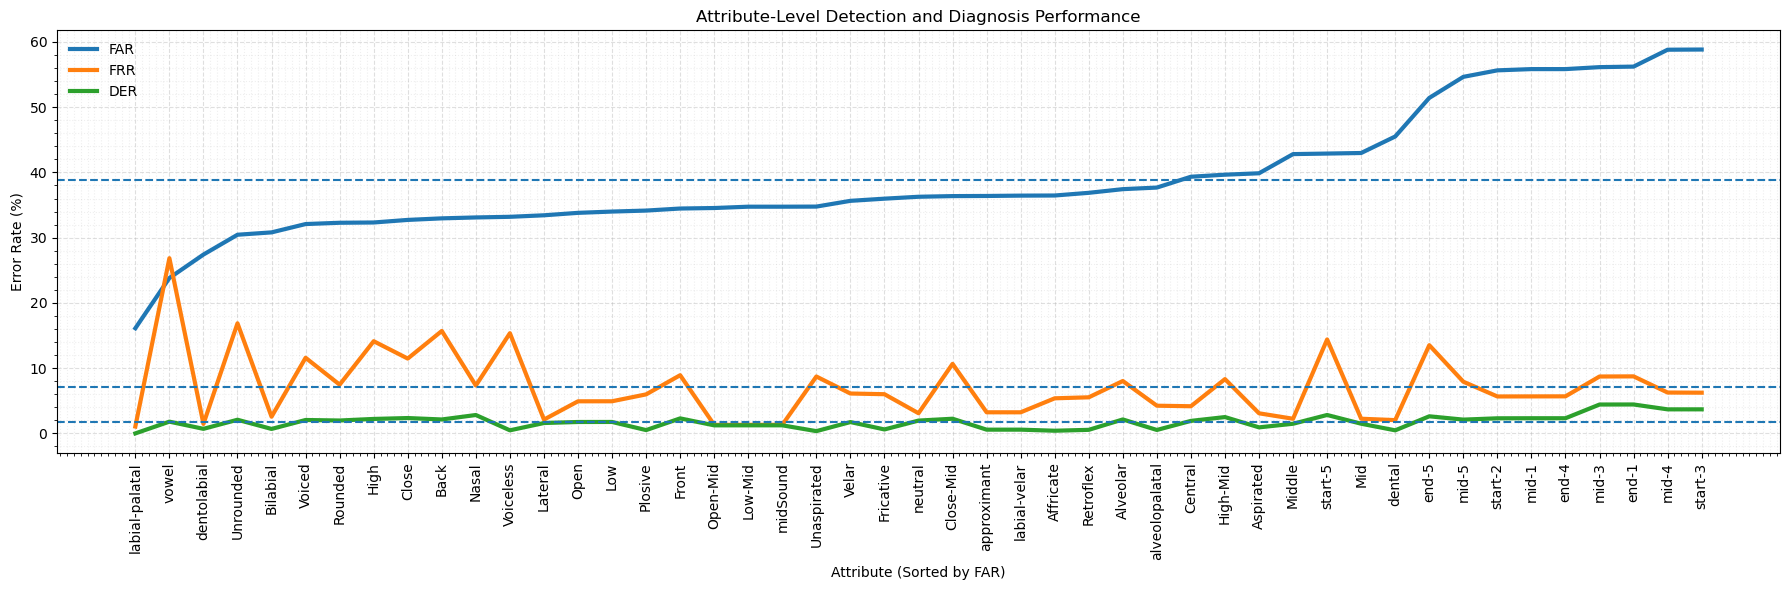

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(results)
df = df.sort_values("FAR%").reset_index(drop=True)

# ---- 计算 mean ----
far_mean = df["FAR%"].mean()
frr_mean = df["FRR%"].mean()
der_mean = df["DER%"].mean()

plt.figure(figsize=(18,6))

# ---- 曲线 ----
plt.plot(df["FAR%"], linewidth=3, label=f"FAR")
plt.plot(df["FRR%"], linewidth=3, label=f"FRR")
plt.plot(df["DER%"], linewidth=3, label=f"DER")

# ---- Mean 横线 ----
plt.axhline(far_mean, linestyle="--", linewidth=1.5)
plt.axhline(frr_mean, linestyle="--", linewidth=1.5)
plt.axhline(der_mean, linestyle="--", linewidth=1.5)

# ---- X轴 ----
plt.xticks(np.arange(len(df)), df["attr"], rotation=90)

plt.ylabel("Error Rate (%)")
plt.xlabel("Attribute (Sorted by FAR)")
plt.title("Attribute-Level Detection and Diagnosis Performance")

# ---- Grid（主 + 次）----
plt.grid(True, which="major", linestyle="--", alpha=0.4)
plt.minorticks_on()
plt.grid(True, which="minor", linestyle=":", alpha=0.2)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()